In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from src.config import DIR_ENG, LOAD_RAW_DATA, LOAD_PROCESSED_DATA

In [2]:
data = pd.read_csv(LOAD_RAW_DATA/"training_dataset.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
data["SalePrice_log"] = np.log(data["SalePrice"])
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247694
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109011
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317167
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849398
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429216


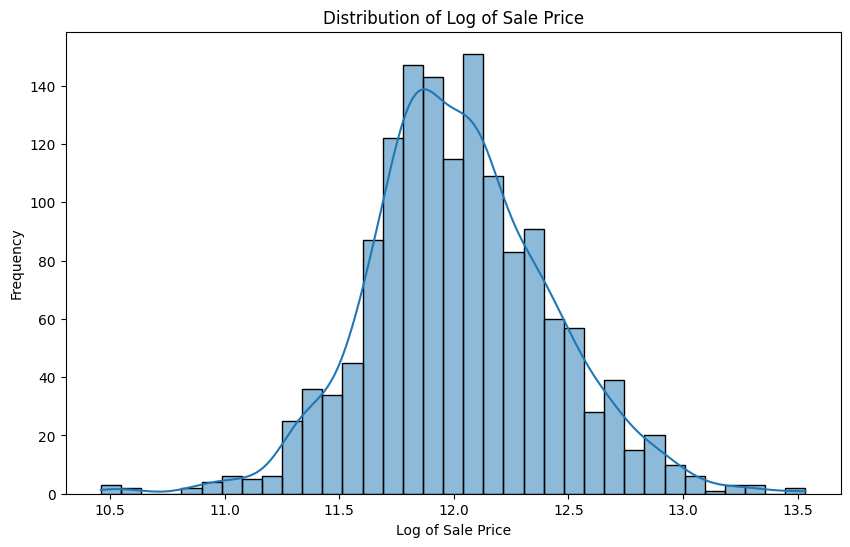

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data["SalePrice_log"], kde=True)
plt.title("Distribution of Log of Sale Price")
plt.xlabel("Log of Sale Price")
plt.ylabel("Frequency")

plt.savefig(DIR_ENG/"histplots/Distribution_of_log_saleprice_histplot.png")

plt.show()


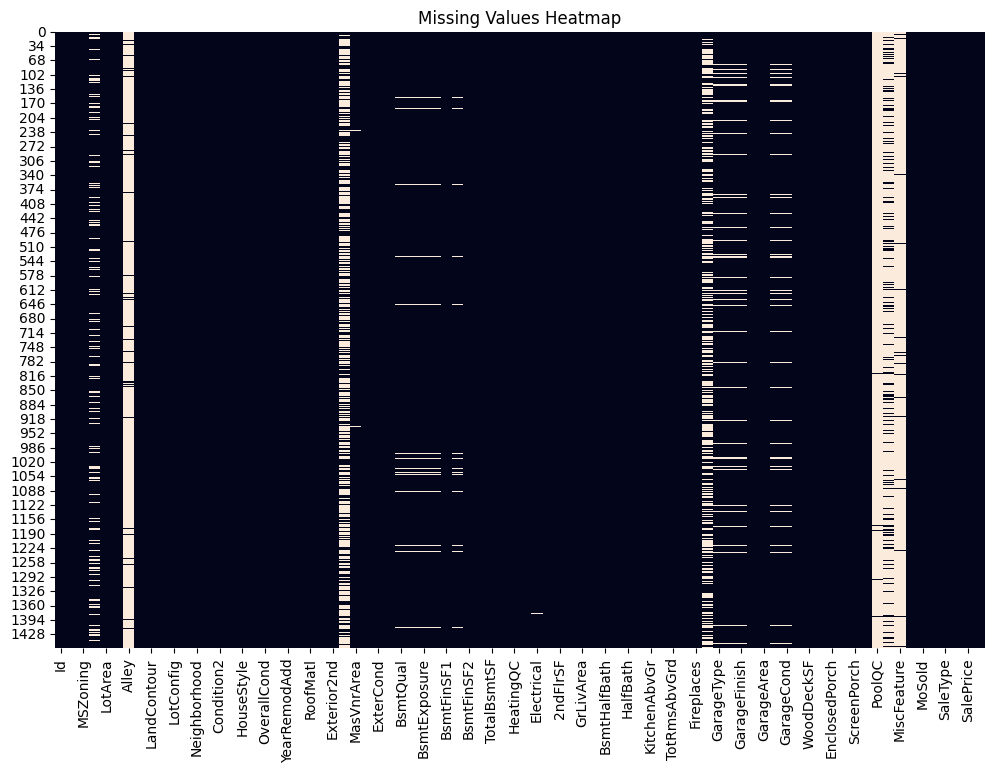

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")

plt.savefig(DIR_ENG/"Heatmaps/Missing_values_heatmap.png")

plt.show()

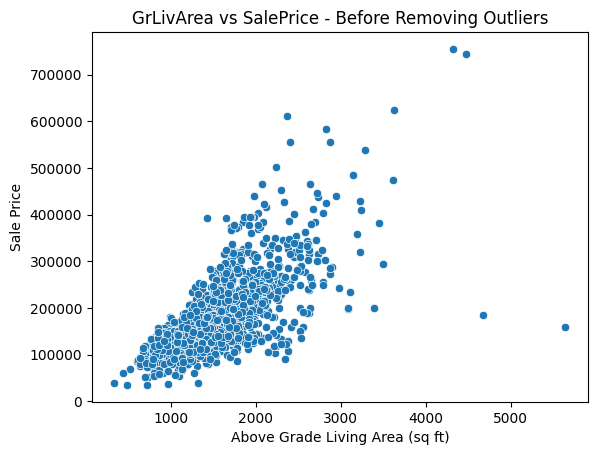

In [6]:
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.title("GrLivArea vs SalePrice - Before Removing Outliers")
plt.xlabel("Above Grade Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.savefig(DIR_ENG/"Scatterplots/GrLivArea_vs_SalePrice_before_outlier_removal.png")

plt.show()

In [7]:
clean_data = pd.read_csv(LOAD_PROCESSED_DATA/"x_train_processed.csv")
clean_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RL,70.0,8400,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,6,2010,WD,Normal
1,60,RL,59.0,7837,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,40,0,0,0,0,0,5,2009,WD,Normal
2,30,RL,67.0,8777,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,164,0,0,0,0,5,2008,WD,Normal
3,50,RL,60.0,7200,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,264,0,0,0,0,6,2007,WD,Normal
4,50,RL,50.0,5000,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,242,0,0,0,0,5,2010,WD,Normal


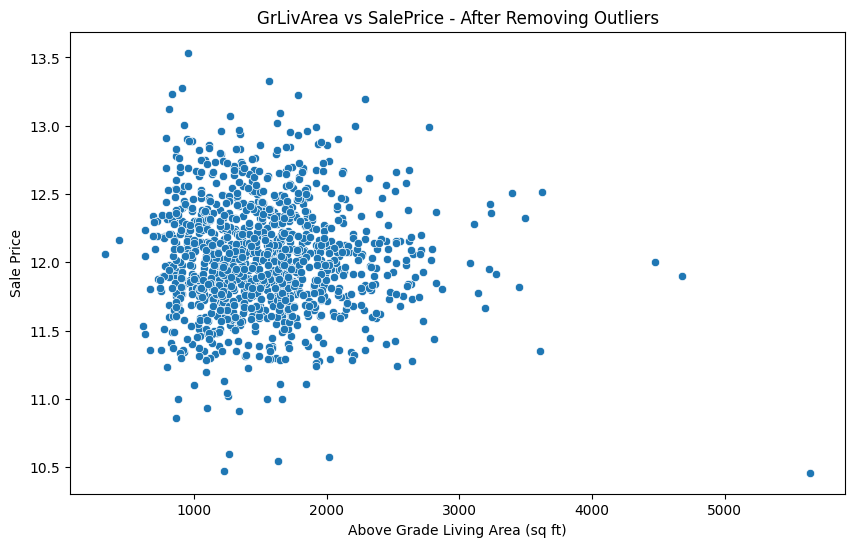

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x =clean_data["GrLivArea"], y=np.log1p(data["SalePrice"]))
plt.title("GrLivArea vs SalePrice - After Removing Outliers")
plt.xlabel("Above Grade Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.savefig(DIR_ENG/"Scatterplots/GrLivArea_vs_SalePrice_after_outlier_removal.png")
plt.show()

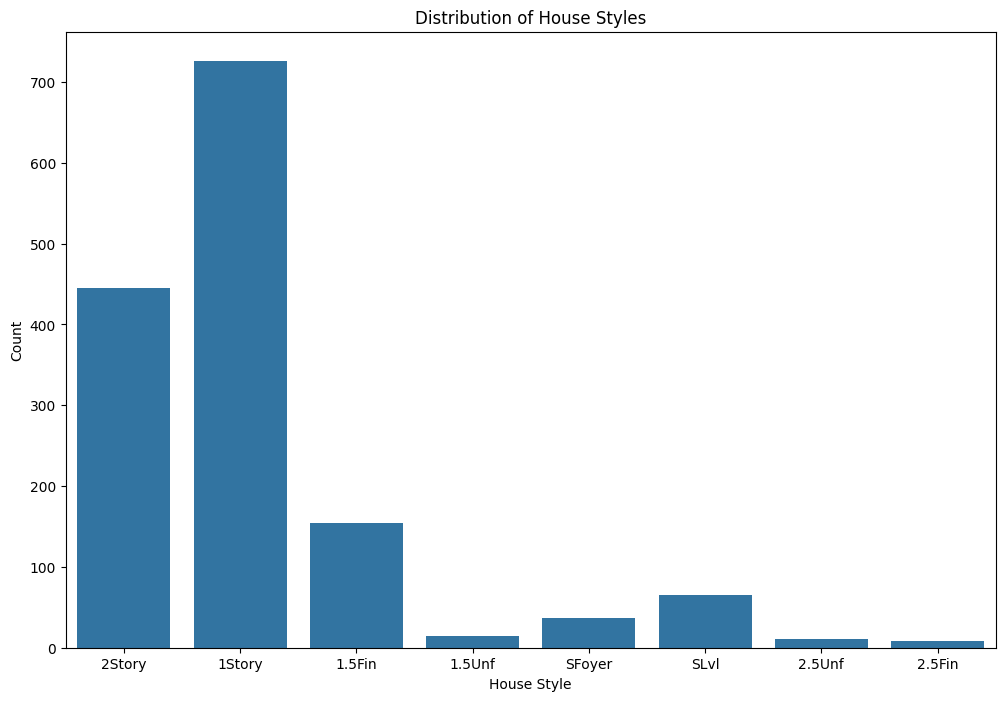

In [9]:
plt.figure(figsize=(12, 8))
sns.countplot(x=data["HouseStyle"])
plt.title("Distribution of House Styles")
plt.xlabel("House Style")
plt.ylabel("Count")

plt.savefig(DIR_ENG/"Countplots/Distribution_of_house_styles_countplot.png")
plt.show()